In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt


In [2]:
offers = pd.read_csv(r'C:\Users\UDIT NARAYAN KAUSHIK\Downloads\Gett_Dataset\data_offers.csv')
orders = pd.read_csv(r'C:\Users\UDIT NARAYAN KAUSHIK\Downloads\Gett_Dataset\data_orders.csv')

In [3]:
# Merging both data frames


merged = pd.merge(orders, offers, on = 'order_gk')

merged = merged.rename(
   columns={
    'order_status_key': 'order_status',
    'is_driver_assigned_key': 'driver_assigned'
})

merged.head()




,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status,driver_assigned,cancellations_time_in_seconds,offer_id
0,18:08:07,-0.978916,51.456173,60.0,3000583041974,4,1,198.0,300050983403
1,20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0,300050986179
2,20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0,300050986174
3,20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0,300050986180
4,12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0,300050976275


In [4]:
# Changing column value type to string 

merged["driver_assigned"] = np.where(merged["driver_assigned"] == 1, "Yes", "No")
merged["order_status"] = np.where(merged["order_status"] == 4, "User Cancelled", "System Reject")

merged[['order_status', 'driver_assigned']].value_counts()

order_status    driver_assigned
User Cancelled  No                 13435
System Reject   No                  9469
User Cancelled  Yes                 8360
System Reject   Yes                    4
Name: count, dtype: int64

In [5]:
# Group and count orders

orders_count = merged.groupby(['order_status', 'driver_assigned'])['order_gk'].count().reset_index()

orders_count.head()

,order_status,driver_assigned,order_gk
0,System Reject,No,9469
1,System Reject,Yes,4
2,User Cancelled,No,13435
3,User Cancelled,Yes,8360


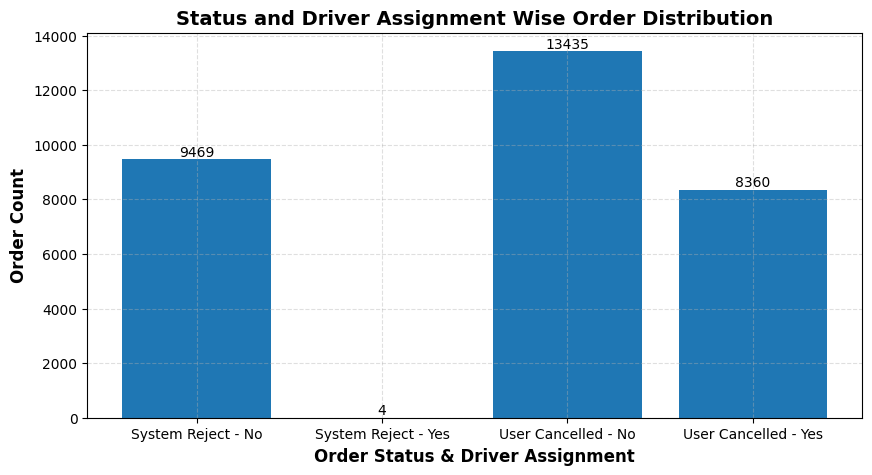

In [6]:
# Task 1 - Build up a distribution of orders according to reasons for failure: cancellations before and after driver assignment,
# and reasons for order rejection. Analyse the resulting plot. Which category has the highest number of orders?


# Create combined label
orders_count['label'] = (orders_count['order_status'] + " - " + orders_count['driver_assigned'])

# Plot
plt.figure(figsize=(10,5))

bars = plt.bar(orders_count['label'], orders_count['order_gk'])

# When multi color bars are required
# bars = plt.bar(orders_count['label'], orders_count['order_gk'], color= ['blue', 'orange', 'green'])


# bar labels - to show exact count on bars
plt.bar_label(bars)

plt.xlabel("Order Status & Driver Assignment",
           fontsize=12, fontweight='bold')

plt.ylabel("Order Count",
           fontsize=12, fontweight='bold')

plt.title("Status and Driver Assignment Wise Order Distribution",
          fontsize=14, fontweight='bold')

# plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

In [7]:
merged.loc[
    merged['cancellations_time_in_seconds'].isnull(),
    'order_status'
].unique()

array(['System Reject'], dtype=object)

In [8]:
# extract hour from the time column
merged['order_datetime'] = pd.to_datetime(merged['order_datetime'])

merged['hour'] = merged['order_datetime'].dt.hour

merged['hour'].unique()

C:\Users\UDIT NARAYAN KAUSHIK\AppData\Local\Temp\ipykernel_2444\3480554604.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged['order_datetime'] = pd.to_datetime(merged['order_datetime'])


array([18, 20, 12, 13, 21,  7,  8,  6, 15,  0, 22,  1,  3, 16, 14, 17, 19,
        9, 23, 11,  2,  4, 10,  5], dtype=int32)

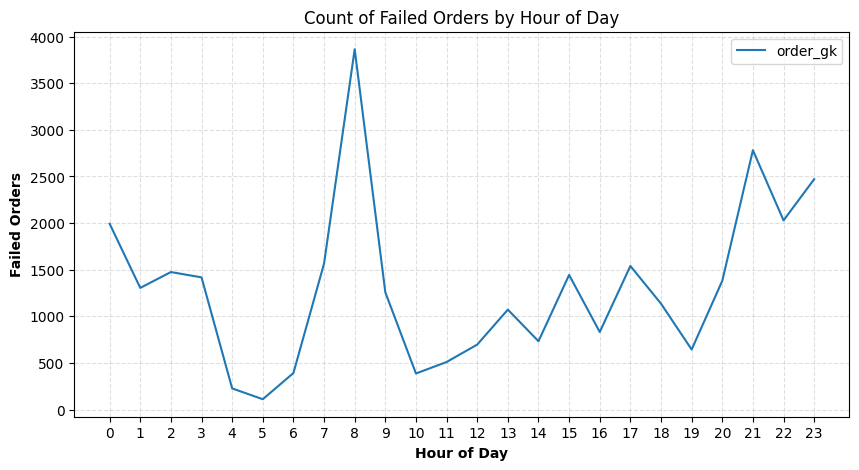

In [9]:
# Task - 2

# Plot the distribution of failed orders by hours. 
# Is there a trend that certain hours have an abnormally high proportion of one category or another?
# What hours are the biggest fails? How can this be explained?

# Part 1 - Cancelled Order per hour
merged.groupby(by='hour')['order_gk'].count().plot(
    figsize=(10, 5),
    legend=True,
    xticks=range(0, 24),
    title='Count of Failed Orders by Hour of Day'
)

plt.xlabel('Hour of Day', fontsize=10, fontweight='bold')
plt.ylabel('Failed Orders', fontsize=10, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()



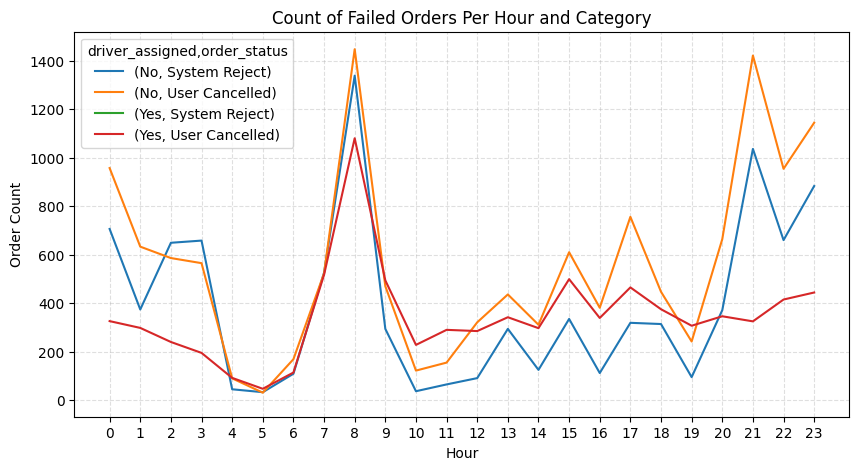

In [10]:
#Task 2 (Part 2) - 

# Cancelled order per hour by category
merged.pivot_table(
    index='hour',
    columns=['driver_assigned', 'order_status'],
    values='order_gk',
    aggfunc='count'
).plot(
    xticks=range(0, 24),
    figsize=(10, 5),
    title='Count of Failed Orders Per Hour and Category'
)

plt.xlabel('Hour')
plt.ylabel('Order Count')

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

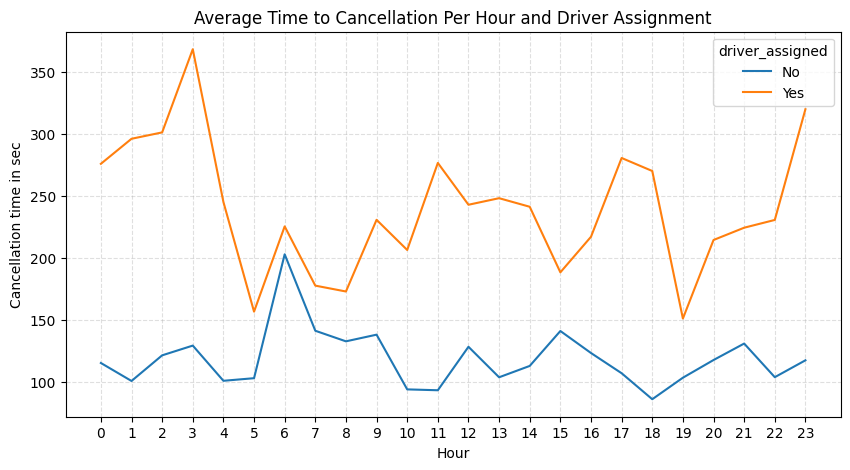

In [11]:
# Task 3 -
# Plot the average time to cancellation with and without driver, by hour. Can we draw any conclusions from this plot?


task3 = merged.groupby(by=['hour', 'driver_assigned'])['cancellations_time_in_seconds'].mean()

task3.reset_index().pivot(index="hour",
                          columns="driver_assigned",
values="cancellations_time_in_seconds").plot(xticks=range(0, 24),
                                            figsize=(10, 5),
                                            title="Average Time to Cancellation Per Hour and Driver Assignment")
plt.xlabel('Hour')
plt.ylabel('Cancellation time in sec')

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()


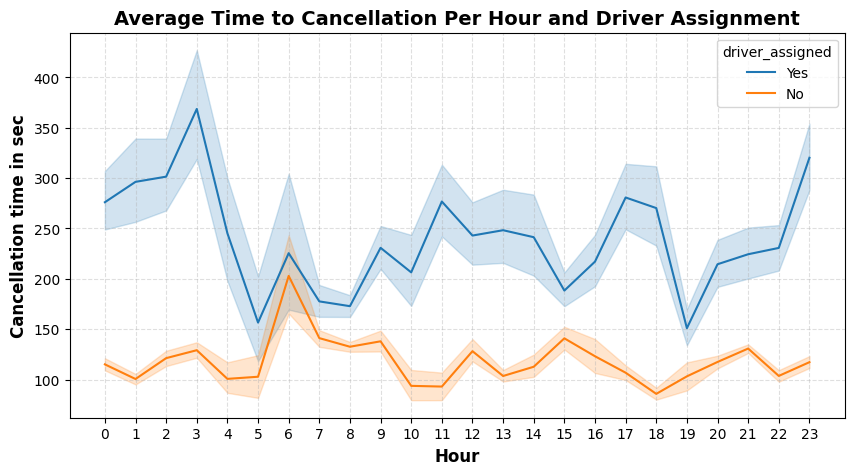

In [12]:
# Task 3 using seaborn

plt.figure(figsize=(10, 5))

sb.lineplot(
    data=merged,
    x='hour',
    y='cancellations_time_in_seconds',
    hue='driver_assigned',
    estimator='mean'   # this replaces groupby mean
)

plt.title("Average Time to Cancellation Per Hour and Driver Assignment", fontsize = 14 , fontweight = 'bold')
plt.xlabel("Hour", fontsize = 12 , fontweight = 'bold')
plt.ylabel("Cancellation time in sec", fontsize = 12 , fontweight = 'bold')

plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

In [ ]:
merged.head()

In [13]:
merged = merged.rename(columns={'m_order_eta': 'Order_ETA'})
merged.head()

,order_datetime,origin_longitude,origin_latitude,Order_ETA,order_gk,order_status,driver_assigned,cancellations_time_in_seconds,offer_id,hour
0,2026-05-24 18:08:07,-0.978916,51.456173,60.0,3000583041974,User Cancelled,Yes,198.0,300050983403,18
1,2026-05-24 20:57:32,-0.950385,51.456843,NaN,3000583116437,User Cancelled,No,128.0,300050986179,20
2,2026-05-24 20:57:32,-0.950385,51.456843,NaN,3000583116437,User Cancelled,No,128.0,300050986174,20
3,2026-05-24 20:57:32,-0.950385,51.456843,NaN,3000583116437,User Cancelled,No,128.0,300050986180,20
4,2026-05-24 12:07:50,-0.969520,51.455544,477.0,3000582891479,User Cancelled,Yes,46.0,300050976275,12


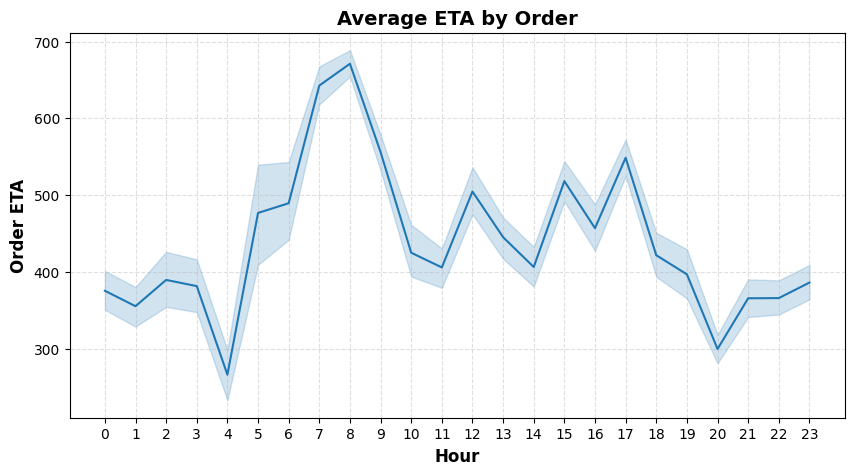

In [14]:
# Task 4 - 
# Plot the distribution of average ETA by hours. How can this plot be explained?

plt.figure(figsize=(10, 5))

sb.lineplot(
    data = merged,
    x= 'hour',
    y='Order_ETA',
    estimator = 'mean'
)
plt.title("Average ETA by Order", fontsize = 14 , fontweight = 'bold')
plt.xlabel("Hour", fontsize = 12 , fontweight = 'bold')
plt.ylabel("Order ETA", fontsize = 12 , fontweight = 'bold')

plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()
